# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

# Prioritising Content Review with Machine Learning

### A leakage-aware, client-grouped ranking study on anonymised search data

## Abstract

Content teams with limited review capacity need a defensible way to decide which pages to
investigate first. I framed this as a ranking problem and used anonymised FlyRank search,
content and engagement signals with a rule-derived recent-decline proxy as the evaluation
target. Logistic Regression and Random Forest models were compared with an impressions-only
baseline using a client-grouped holdout that kept all pages from each client entirely in
training or test data. On nine unseen test clients, the Random Forest measured
**Precision@50 = 0.720**, compared with **0.520** for the impressions-only baseline, with
**ROC-AUC = 0.612**. These results provide directional evidence for a human-reviewed
content-prioritisation queue, not evidence of prospective decline prediction or causal benefit
from refreshing content.

## Research question

**Can a learned combination of page-level search, content and engagement signals rank
content-review opportunities more effectively than a simple demand-based baseline while
generalising across unseen clients?**

The decision supported by this work is practical: when a content or SEO reviewer can inspect
only a limited number of pages each week, which pages should be reviewed first?

A false positive consumes scarce reviewer capacity. A false negative can leave a page showing
the decline proxy outside the current review queue. Therefore, the useful output is an ordered
queue rather than merely a yes/no classification.

In [3]:
import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_DIR = "/content/flyrank-ml"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/SuryaK5125/flyrank-ml.git {REPO_DIR}

%cd /content/flyrank-ml

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

df = pd.read_csv(
    "data/raw/content_refresh_anonymized.csv"
)

print("Starter dataset shape:", df.shape)
print("Starter clients:", df["client_id"].nunique())
print("\nTrend-direction counts:")
print(df["trend_direction"].value_counts(dropna=False))

/content/flyrank-ml
Starter dataset shape: (30000, 44)
Starter clients: 32

Trend-direction counts:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


## 2. Data

This project used two related FlyRank data layers for different purposes.

### Production-scale warehouse

The production-scale environment is the gated `FlyRank/internship-warehouse` release
**v20260703**. Its main daily fact table,
`fact_content_daily_performance`, contains approximately **78.8 million daily rows**.
The warehouse also contains pseudonymised client and content dimensions.

In Week 3 I queried the warehouse directly with DuckDB over Hugging Face Parquet rather than
downloading it into memory. I deliberately inspected the real schema before constructing
queries because several field names differed from earlier assumptions.

For the verified March 2026 partition:

- window: **2026-03-01 to 2026-03-31**
- rows: **9,841,378**
- source: `fact_content_daily_performance`
- content metadata such as creation date came from `dim_content`
- `content_age_days` had to be computed from `content_created_date` and `report_date`

The sealed final month was not used for this exploratory warehouse exercise.

### Final modelling dataset

The final ranking model in this paper uses the anonymised starter snapshot
`content_refresh_anonymized.csv`.

It contains **30,000 rows and 44 columns**, with one row representing one content page.

After requiring all final model features, the target and client grouping field to be available,
**19,897 rows** remained for modelling. This complete-case requirement excluded 10,103 rows
(33.68% of the original snapshot), so model-performance claims apply to this evaluated
population rather than automatically to every page in the source dataset.

No client names, URLs, raw search queries or other identifying content are used in this paper.
Pseudonymous identifiers are used only where required for grouping or internal queue generation.

In [4]:
# Starter-data receipt

feature_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
]

model_df = df.dropna(
    subset=feature_cols
    + ["trend_direction", "client_id"]
).copy()

model_df["label"] = (
    model_df["trend_direction"] == "down"
).astype(int)

starter_receipt = pd.DataFrame({
    "item": [
        "Raw rows",
        "Raw columns",
        "Raw clients",
        "Complete-case model rows",
        "Complete-case clients",
        "Rows excluded",
        "Percent excluded",
        "Raw decline rate",
        "Complete-case decline rate",
    ],
    "value": [
        len(df),
        df.shape[1],
        df["client_id"].nunique(),
        len(model_df),
        model_df["client_id"].nunique(),
        len(df) - len(model_df),
        round(
            100 * (1 - len(model_df) / len(df)),
            2
        ),
        round(
            df["trend_direction"].eq("down").mean(),
            4
        ),
        round(
            model_df["label"].mean(),
            4
        ),
    ]
})

display(starter_receipt)

# Re-verify the March warehouse partition

import duckdb
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf
    (
        TYPE huggingface,
        TOKEN '{hf_token}'
    )
    """
)

REL = "hf://datasets/FlyRank/internship-warehouse"

MARCH = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/"
    f"month=2026-03/*.parquet'"
    f")"
)

march_receipt = con.sql(
    f"""
    SELECT
        COUNT(*) AS rows,
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date,
        SUM(
            CASE
                WHEN ga4_data_available IS TRUE
                THEN 1 ELSE 0
            END
        ) AS ga4_available_rows
    FROM {MARCH}
    """
).df()

display(march_receipt)

,item,value
0,Raw rows,30000.0000
1,Raw columns,44.0000
2,Raw clients,32.0000
3,Complete-case model rows,19897.0000
4,Complete-case clients,29.0000
5,Rows excluded,10103.0000
6,Percent excluded,33.6800
7,Raw decline rate,0.5421
8,Complete-case decline rate,0.6008


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,min_date,max_date,ga4_available_rows
0,9841378,2026-03-01,2026-03-31,413966.0


## 3. Methodology

### Task framing

Although the target is binary, the business task is **ranking/scoring**, not simply
classification. A reviewer has a fixed capacity, so the important question is whether genuinely
declining-proxy pages appear near the top of the queue.

The primary operational metric is therefore **Precision@50**.

### Target

The modelling target is:

`is_declining_label = (trend_direction == "down")`

This is a **rule-derived proxy for observed recent decline**, not a true future outcome.
`trend_direction` is derived from `trend_pct`, so neither field is allowed as a model feature.

### Features

The final model uses 14 page-level features covering search demand, content characteristics,
recent traffic, search position and engagement:

`search_volume`, `competition`, `cpc`, `word_count`, `char_count`,
`impressions_90d`, `clicks_90d`, `sessions_90d`, `content_age_days`,
`days_since_last_update`, `ctr`, `avg_position`, `engagement_rate`,
and `scroll_rate`.

Identifiers and existing product-decision fields are excluded.

### Baseline

The honest baseline ranks all test pages using only `impressions_90d`.

This deliberately simple baseline represents the intuitive rule:

**"Review the pages with the most search visibility first."**

It does not use the target as a gate or multiplier.

### Models

I compare:

- Logistic Regression — simple and readable
- Random Forest — able to combine weak nonlinear signals while remaining inspectable through
  feature importance

### Validation design

The primary validation uses a **70/30 GroupShuffleSplit grouped by `client_id`**.

All pages belonging to one client remain entirely in either training or test data. The final
split contains **20 training clients and 9 held-out clients with zero client overlap**.

This tests the more relevant question:

**Can the ranking transfer to clients not seen during training?**

### Leakage checks

The audit included:

1. explicit removal of the target and label-source fields;
2. exclusion of IDs and existing product-decision outputs;
3. comparison of row-random and client-grouped validation;
4. a deliberate leakage test using `trend_pct`.

The deliberate leak caused Random Forest ROC-AUC and Precision@50 to reach 1.000, confirming
that target-derived information can produce misleadingly perfect metrics.

The grouped split addresses client overlap, but does not create temporal separation between
the 90-day inputs and the current decline proxy. That limitation is treated explicitly below.

In [5]:
def precision_at_k(scores, labels, k=50):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    order = np.argsort(-scores)

    return labels[
        order[:k]
    ].mean()

# Primary grouped split

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        model_df,
        groups=model_df["client_id"]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

assert len(
    set(train_df["client_id"])
    & set(test_df["client_id"])
) == 0

# Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    train_df[feature_cols]
)

X_test_scaled = scaler.transform(
    test_df[feature_cols]
)

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(
    X_train_scaled,
    train_df["label"]
)

logreg_scores = logreg.predict_proba(
    X_test_scaled
)[:, 1]

# Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(
    train_df[feature_cols],
    train_df["label"]
)

rf_scores = rf.predict_proba(
    test_df[feature_cols]
)[:, 1]


baseline_scores = (
    test_df["impressions_90d"].values
)

# Main grouped metrics

base_rate = test_df["label"].mean()

baseline_p50 = precision_at_k(
    baseline_scores,
    test_df["label"].values,
    50
)

logreg_p50 = precision_at_k(
    logreg_scores,
    test_df["label"].values,
    50
)

rf_p50 = precision_at_k(
    rf_scores,
    test_df["label"].values,
    50
)

logreg_auc = roc_auc_score(
    test_df["label"],
    logreg_scores
)

rf_auc = roc_auc_score(
    test_df["label"],
    rf_scores
)

# Random-row sensitivity comparison

random_train, random_test = train_test_split(
    model_df,
    test_size=0.30,
    random_state=42,
    stratify=model_df["label"]
)

random_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

random_rf.fit(
    random_train[feature_cols],
    random_train["label"]
)

random_rf_scores = random_rf.predict_proba(
    random_test[feature_cols]
)[:, 1]

random_rf_p50 = precision_at_k(
    random_rf_scores,
    random_test["label"].values,
    50
)

random_rf_auc = roc_auc_score(
    random_test["label"],
    random_rf_scores
)

random_client_overlap = len(
    set(random_train["client_id"])
    & set(random_test["client_id"])
)

# Deliberate leakage test

leaky_train = train_df.copy()
leaky_test = test_df.copy()

leaky_train["trend_pct_leak"] = (
    leaky_train["trend_pct"].fillna(0)
)

leaky_test["trend_pct_leak"] = (
    leaky_test["trend_pct"].fillna(0)
)

leaky_features = (
    feature_cols + ["trend_pct_leak"]
)

leaky_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

leaky_rf.fit(
    leaky_train[leaky_features],
    leaky_train["label"]
)

leaky_scores = leaky_rf.predict_proba(
    leaky_test[leaky_features]
)[:, 1]

leaky_p50 = precision_at_k(
    leaky_scores,
    leaky_test["label"].values,
    50
)

leaky_auc = roc_auc_score(
    leaky_test["label"],
    leaky_scores
)


print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train clients:", train_df["client_id"].nunique())
print("Test clients:", test_df["client_id"].nunique())
print("Grouped client overlap:", 0)

print()
print("Grouped RF P@50:", round(rf_p50, 3))
print("Grouped RF AUC:", round(rf_auc, 3))
print("Random RF P@50:", round(random_rf_p50, 3))
print("Random RF AUC:", round(random_rf_auc, 3))
print("Random client overlap:", random_client_overlap)

print()
print("Leaky RF P@50:", round(leaky_p50, 3))
print("Leaky RF AUC:", round(leaky_auc, 3))

Train rows: 14114
Test rows: 5783
Train clients: 20
Test clients: 9
Grouped client overlap: 0

Grouped RF P@50: 0.72
Grouped RF AUC: 0.612
Random RF P@50: 0.94
Random RF AUC: 0.752
Random client overlap: 28

Leaky RF P@50: 1.0
Leaky RF AUC: 1.0


## 4. Results (vs baseline)

All headline comparisons below use the **same client-grouped test split**.

| Method | Precision@50 | ROC-AUC |
|---|---:|---:|
| Impressions-only baseline | **0.520** | — |
| Logistic Regression | **0.720** | **0.586** |
| Random Forest | **0.720** | **0.612** |
| Test-set decline prevalence | **0.623** | — |

Both learned models placed **36 decline-proxy pages among the first 50 ranked pages**.

The impressions-only baseline placed 26 decline-proxy pages among its first 50. This shows that
high visibility alone is not a reliable decline-ranking rule.

The Random Forest and Logistic Regression tie on the operational Precision@50 metric. Random
Forest has somewhat higher ROC-AUC, so it provides stronger overall ranking discrimination in
this holdout, but the difference is modest.

### Why validation design matters

Under a row-random split, the Random Forest measured:

- Precision@50 = **0.940**
- ROC-AUC = **0.752**
- overlapping test clients = **28**

Under the client-grouped split:

- Precision@50 = **0.720**
- ROC-AUC = **0.612**
- overlapping clients = **0**

The row-random design therefore produced a substantially more optimistic estimate for the
harder cross-client generalisation problem.

I do not attribute the entire performance gap purely to leakage because the grouped and random
test populations also differ in composition. For the paper's substantive claims, I use the
client-grouped result.

,Method,Precision@50,ROC-AUC
0,Impressions baseline,0.520,NaN
1,Test-set prevalence,0.623,NaN
2,Logistic Regression,0.720,0.586
3,Random Forest,0.720,0.612


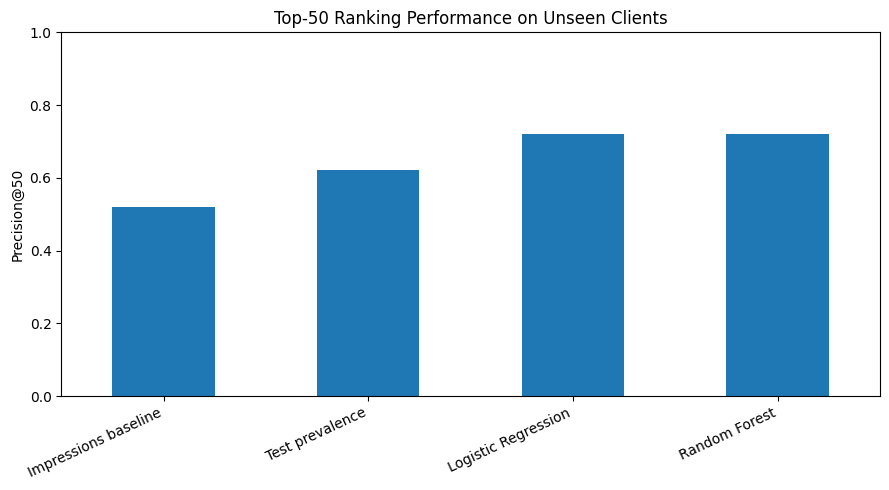

,Random row split,Client-grouped split
Precision@50,0.940,0.720
ROC-AUC,0.752,0.612


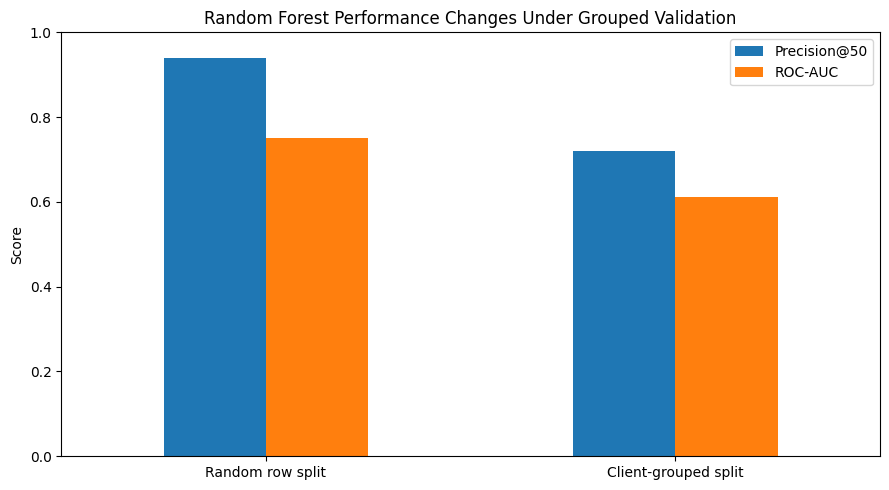

In [6]:
os.makedirs(
    "work/figures",
    exist_ok=True
)

results_table = pd.DataFrame({
    "Method": [
        "Impressions baseline",
        "Test-set prevalence",
        "Logistic Regression",
        "Random Forest",
    ],
    "Precision@50": [
        baseline_p50,
        base_rate,
        logreg_p50,
        rf_p50,
    ],
    "ROC-AUC": [
        np.nan,
        np.nan,
        logreg_auc,
        rf_auc,
    ]
})

display(
    results_table.round(3)
)
# Figure 1 — main Precision@50 comparison

fig1_data = pd.Series({
    "Impressions baseline": baseline_p50,
    "Test prevalence": base_rate,
    "Logistic Regression": logreg_p50,
    "Random Forest": rf_p50,
})

plt.figure(figsize=(9, 5))

fig1_data.plot(kind="bar")

plt.ylabel("Precision@50")
plt.xlabel("")
plt.title(
    "Top-50 Ranking Performance on Unseen Clients"
)

plt.ylim(0, 1)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

FIG1 = (
    "work/figures/"
    "capstone_precision_at_50.png"
)

plt.savefig(
    FIG1,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Figure 2 — validation sensitivity

validation_table = pd.DataFrame({
    "Random row split": [
        random_rf_p50,
        random_rf_auc,
    ],
    "Client-grouped split": [
        rf_p50,
        rf_auc,
    ],
}, index=[
    "Precision@50",
    "ROC-AUC",
])

display(
    validation_table.round(3)
)

validation_table.T.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Score")
plt.xlabel("")
plt.title(
    "Random Forest Performance Changes Under Grouped Validation"
)

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.tight_layout()

FIG2 = (
    "work/figures/"
    "capstone_validation_sensitivity.png"
)

plt.savefig(
    FIG2,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 5. Limitations

This work supports a **decision-support ranking claim**, not a causal or prospective prediction
claim.

### 1. The target is a proxy

`trend_direction == "down"` is derived from recent observed performance. It is not a
future-window outcome measured after a prediction date.

The model therefore ranks pages associated with an observed decline proxy; it has not yet been
shown to forecast which pages will decline later.

### 2. Feature and label windows overlap

Several model inputs are trailing-90-day aggregates, while the decline proxy is constructed
from performance within that same broad period.

Client grouping prevents the same client appearing on both sides of validation, but it does
not solve this temporal-overlap limitation.

A stronger capstone successor would use:

**features from days 1–90 → outcome measured only during days 91–120.**

### 3. Complete-case selection changes the evaluated population

Only 19,897 of the 30,000 starter rows contain every required model field.

The decline prevalence is approximately 0.542 in the raw dataset and 0.601 in the complete-case
population. Missingness is therefore not obviously random, so the results should not be assumed
to represent every page.

### 4. Limited held-out client population

The grouped test contains nine unseen clients. This is more defensible than row-random
validation, but it is not proof of universal performance across all future websites or content
types.

### 5. Staleness is not a treatment rule

Earlier analysis found a mixed, non-monotonic relationship between
`days_since_last_update` and decline. Therefore the system does not claim that old pages should
automatically be refreshed.

### 6. Observational ranking does not establish intervention impact

This study does not test whether editing a recommended page causes traffic, ranking or
engagement to improve.

A causal refresh-effect claim would require a prospective intervention or another suitable
causal design.

In [7]:
limitations_receipt = pd.DataFrame({
    "Audit item": [
        "Raw starter rows",
        "Complete-case rows",
        "Rows excluded",
        "Raw decline rate",
        "Complete-case decline rate",
        "Held-out clients",
        "Grouped client overlap",
        "Random-split client overlap",
        "Honest RF ROC-AUC",
        "Deliberately leaky RF ROC-AUC",
    ],
    "Observed value": [
        len(df),
        len(model_df),
        len(df) - len(model_df),
        df["trend_direction"].eq("down").mean(),
        model_df["label"].mean(),
        test_df["client_id"].nunique(),
        0,
        random_client_overlap,
        rf_auc,
        leaky_auc,
    ]
})

display(
    limitations_receipt
)

,Audit item,Observed value
0,Raw starter rows,30000.000000
1,Complete-case rows,19897.000000
2,Rows excluded,10103.000000
3,Raw decline rate,0.542067
4,Complete-case decline rate,0.600794
5,Held-out clients,9.000000
6,Grouped client overlap,0.000000
7,Random-split client overlap,28.000000
8,Honest RF ROC-AUC,0.612471
9,Deliberately leaky RF ROC-AUC,1.000000


## 6. Ranked recommendations

The model score is not the final editorial decision. It determines **which pages a human
reviewer investigates first**.

For the current demonstration, the first **50 pages** form the review queue because
Precision@50 matches the original limited-capacity decision.

Reason codes are attached after ranking to explain what the reviewer should inspect. They do
not use the target or its source.

| Reason / archetype | Suggested human review |
|---|---|
| `visible_low_ctr` | Review title, snippet and search-intent fit |
| `low_engagement_visible` | Review content alignment, usefulness and depth |
| `thin_visible` | Review whether important topic coverage is missing |
| `stale_visible_context` | Check changed facts, SERP conditions and competitor changes |
| `model_priority_only` | Diagnose manually before deciding whether any edit is needed |

### Intended workflow

**Rank → inspect reason codes → review the actual page/context → decide manually.**

Possible human decisions include refresh, rewrite, title/snippet review, consolidation,
no change or continued monitoring.

### What should not be automated

The score should not automatically publish or rewrite content, change metadata, delete or
redirect pages, merge pages, or trigger a refresh solely because a page is old.

It should also not be interpreted as business value or as evidence that an intervention will
increase traffic.

The strongest recommendation supported by the evidence is:

**"Review these pages first and investigate these signals."**

,Top-50 pages
archetype,
model_priority_only,30
visible_low_ctr,18
low_engagement_visible,2


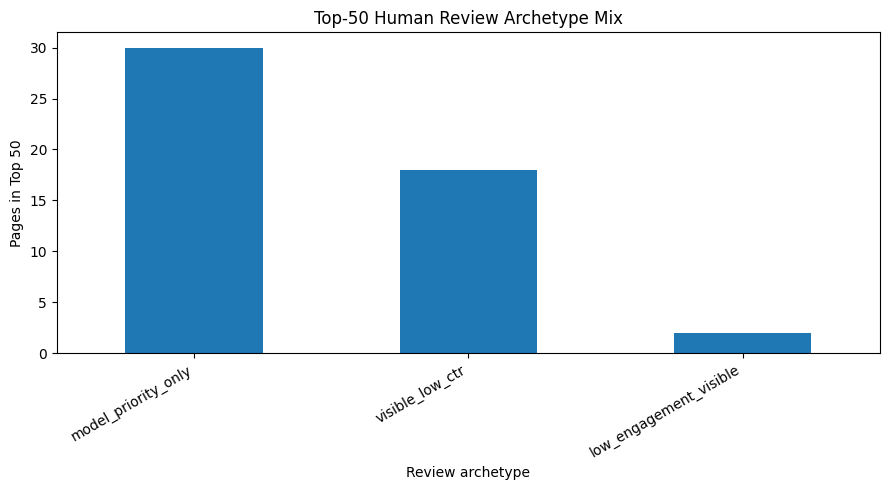

Exported ranked queue rows: 5783


In [8]:
order = np.argsort(-rf_scores)

queue = test_df.iloc[order].copy()

queue["model_score"] = (
    rf_scores[order]
)

queue["rank"] = np.arange(
    1,
    len(queue) + 1
)

REVIEW_CAPACITY = 50

queue["review_status"] = np.where(
    queue["rank"] <= REVIEW_CAPACITY,
    "review_now_top50",
    "monitor_ranked_queue"
)


def make_reason_codes(row):
    reasons = []

    if row["rank"] <= REVIEW_CAPACITY:
        reasons.append(
            "top50_model_priority"
        )

    if (
        row["impressions_90d"] >= 500
        and 0 < row["avg_position"] <= 20
        and row["ctr"] < 0.5
    ):
        reasons.append(
            "visible_low_ctr"
        )

    if (
        row["sessions_90d"] >= 30
        and (
            0 < row["engagement_rate"] < 30
            or 0 < row["scroll_rate"] < 30
        )
    ):
        reasons.append(
            "low_engagement_visible"
        )

    if (
        0 < row["word_count"] < 1200
        and row["impressions_90d"] >= 250
    ):
        reasons.append(
            "thin_visible"
        )

    if (
        row["days_since_last_update"] >= 180
        and row["impressions_90d"] >= 500
    ):
        reasons.append(
            "stale_visible_context"
        )

    contextual = {
        "visible_low_ctr",
        "low_engagement_visible",
        "thin_visible",
        "stale_visible_context",
    }

    if not contextual.intersection(reasons):
        if row["rank"] <= REVIEW_CAPACITY:
            reasons.append(
                "model_priority_only"
            )
        else:
            reasons.append(
                "ranked_monitor"
            )

    return "|".join(reasons)


queue["reason_codes"] = queue.apply(
    make_reason_codes,
    axis=1
)


def assign_archetype(reason_text):
    reasons = set(
        reason_text.split("|")
    )

    if "visible_low_ctr" in reasons:
        return "visible_low_ctr"

    if "low_engagement_visible" in reasons:
        return "low_engagement_visible"

    if "thin_visible" in reasons:
        return "thin_visible"

    if "stale_visible_context" in reasons:
        return "stale_visible_context"

    return "model_priority_only"


queue["archetype"] = (
    queue["reason_codes"]
    .apply(assign_archetype)
)


action_map = {
    "visible_low_ctr":
        "review_title_snippet_and_search_intent",

    "low_engagement_visible":
        "review_content_alignment_and_depth",

    "thin_visible":
        "review_topic_coverage",

    "stale_visible_context":
        "review_freshness_and_competitor_change",

    "model_priority_only":
        "manual_diagnosis_before_edit",
}

queue["suggested_review"] = (
    queue["archetype"]
    .map(action_map)
)


# Public paper only needs aggregate action mix.
top50 = queue[
    queue["rank"] <= REVIEW_CAPACITY
].copy()

action_counts = (
    top50["archetype"]
    .value_counts()
    .sort_values(ascending=False)
)

display(
    action_counts.rename(
        "Top-50 pages"
    ).to_frame()
)


plt.figure(figsize=(9, 5))

action_counts.plot(
    kind="bar"
)

plt.ylabel("Pages in Top 50")
plt.xlabel("Review archetype")
plt.title(
    "Top-50 Human Review Archetype Mix"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

FIG3 = (
    "work/figures/"
    "capstone_action_mix.png"
)

plt.savefig(
    FIG3,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Regeneratable, gitignored queue
os.makedirs(
    "work/outputs",
    exist_ok=True
)

queue_export_cols = [
    "rank",
    "content_id",
    "model_score",
    "review_status",
    "reason_codes",
    "archetype",
    "suggested_review",
    "impressions_90d",
    "clicks_90d",
    "avg_position",
    "ctr",
    "content_age_days",
    "days_since_last_update",
]

queue[
    queue_export_cols
].to_csv(
    "work/outputs/"
    "capstone_ranked_action_queue.csv",
    index=False
)

print(
    "Exported ranked queue rows:",
    len(queue)
)

## 7. Artifacts the paper embeds

The deployed page uses three figures generated directly from the executed capstone:

1. **Top-50 ranking performance** — Random Forest and Logistic Regression compared with the
   impressions baseline and test-set prevalence.
2. **Validation sensitivity** — Random Forest under row-random versus client-grouped
   validation.
3. **Top-50 action mix** — the human-review archetypes produced by the action playbook.

The deployed paper also contains:

- Title + Abstract
- Introduction / Problem
- Data
- Methodology
- Results
- Limitations & honest framing
- Ranked recommendations
- Reproducibility
- Acknowledgments & data credit

The public page contains aggregate results only. The ranked row-level queue remains in
`work/outputs/` and is regenerated by the notebook rather than committed as public data.

In [39]:
# ============================================================
# SECTION 7 — BUILD POLISHED PUBLIC RESEARCH PAGE
# ============================================================

import os
import json
import shutil
from pathlib import Path

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

AUTHOR = "Surya"
REPO_URL = "https://github.com/SuryaK5125/flyrank-ml"

DOCS_DIR = Path("docs")
IMG_DIR = DOCS_DIR / "img"

DOCS_DIR.mkdir(exist_ok=True)
IMG_DIR.mkdir(exist_ok=True)
Path("work/outputs").mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Copy capstone figures into GitHub Pages assets
# ------------------------------------------------------------

for src in [FIG1, FIG2, FIG3]:
    src_path = Path(src)

    if not src_path.exists():
        raise FileNotFoundError(
            f"Expected figure not found: {src_path}"
        )

    shutil.copy(
        src_path,
        IMG_DIR / src_path.name
    )


# ------------------------------------------------------------
# Metrics receipt
# ------------------------------------------------------------

metrics_receipt = {
    "warehouse_release": "v20260703",

    "warehouse_march_rows":
        int(march_receipt.loc[0, "rows"]),

    "starter_rows":
        int(len(df)),

    "complete_case_rows":
        int(len(model_df)),

    "train_rows":
        int(len(train_df)),

    "test_rows":
        int(len(test_df)),

    "train_clients":
        int(train_df["client_id"].nunique()),

    "test_clients":
        int(test_df["client_id"].nunique()),

    "client_overlap": 0,

    "test_base_rate":
        float(base_rate),

    "baseline_precision_at_50":
        float(baseline_p50),

    "logreg_precision_at_50":
        float(logreg_p50),

    "logreg_roc_auc":
        float(logreg_auc),

    "rf_precision_at_50":
        float(rf_p50),

    "rf_roc_auc":
        float(rf_auc),

    "random_rf_precision_at_50":
        float(random_rf_p50),

    "random_rf_roc_auc":
        float(random_rf_auc),

    "deliberate_leak_rf_roc_auc":
        float(leaky_auc),

    "review_capacity":
        int(REVIEW_CAPACITY),

    "claim_scope":
        (
            "Decision-support ranking for an observed "
            "decline proxy; not prospective forecasting "
            "or causal intervention evidence."
        ),
}

with open(
    "work/outputs/capstone_metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metrics_receipt,
        f,
        indent=2
    )


# ------------------------------------------------------------
# Dynamic action-mix HTML
# ------------------------------------------------------------

action_rows = ""

for archetype, count in action_counts.items():

    pretty_name = (
        str(archetype)
        .replace("_", " ")
        .title()
    )

    action_rows += f"""
    <div class="action-stat">
        <span class="action-label">{pretty_name}</span>
        <strong>{int(count)}</strong>
    </div>
    """


# ------------------------------------------------------------
# Public research page
# ------------------------------------------------------------

paper_html = f"""<!DOCTYPE html>

<html lang="en">

<head>

<meta charset="utf-8">

<meta
    name="viewport"
    content="width=device-width, initial-scale=1"
>

<meta
    name="description"
    content="A client-grouped machine-learning ranking study for prioritising content review using anonymised FlyRank search data."
>

<title>
Prioritising Content Review with Machine Learning
</title>

<style>

/* =========================================================
   BASE
   ========================================================= */

:root {{
    --navy: #081525;
    --navy-soft: #10253d;
    --blue: #2563eb;
    --blue-light: #dbeafe;
    --cyan: #38bdf8;

    --text: #172033;
    --muted: #64748b;

    --surface: #ffffff;
    --soft: #f5f7fb;
    --soft-blue: #eef5ff;

    --border: #e2e8f0;

    --success: #047857;
    --warning-bg: #fff8e7;
    --warning-border: #f59e0b;

    --shadow:
        0 18px 50px rgba(15, 23, 42, 0.08);

    --radius: 18px;
}}

* {{
    box-sizing: border-box;
}}

html {{
    scroll-behavior: smooth;
}}

body {{
    margin: 0;
    color: var(--text);
    background: var(--surface);

    font-family:
        Inter,
        -apple-system,
        BlinkMacSystemFont,
        "Segoe UI",
        Roboto,
        Arial,
        sans-serif;

    line-height: 1.7;
}}

a {{
    color: var(--blue);
    text-decoration: none;
}}

a:hover {{
    text-decoration: underline;
}}

code {{
    background: #eef2f7;
    border-radius: 5px;
    padding: 2px 6px;

    font-family:
        "SFMono-Regular",
        Consolas,
        monospace;

    font-size: 0.9em;
}}


/* =========================================================
   HERO
   ========================================================= */

.hero {{
    position: relative;
    overflow: hidden;

    background:
        radial-gradient(
            circle at 88% 20%,
            rgba(56, 189, 248, 0.22),
            transparent 32%
        ),
        radial-gradient(
            circle at 12% 90%,
            rgba(37, 99, 235, 0.18),
            transparent 34%
        ),
        linear-gradient(
            135deg,
            #071321,
            #0b1e35 65%,
            #102b4c
        );

    color: white;

    padding:
        26px 24px
        86px;
}}

.hero-inner {{
    width: min(1120px, 92vw);
    margin: 0 auto;
}}

.topbar {{
    display: flex;
    justify-content: space-between;
    align-items: center;

    margin-bottom: 90px;
}}

.brand {{
    font-size: 0.82rem;
    font-weight: 800;
    letter-spacing: 0.12em;
    text-transform: uppercase;

    color: #bae6fd;
}}

.github-link {{
    color: white;

    border:
        1px solid
        rgba(255,255,255,0.24);

    border-radius: 999px;

    padding:
        8px 15px;

    font-size: 0.88rem;
    font-weight: 600;
}}

.github-link:hover {{
    background:
        rgba(255,255,255,0.08);

    text-decoration: none;
}}

.eyebrow {{
    display: inline-block;

    margin-bottom: 20px;

    color: #7dd3fc;

    font-size: 0.8rem;
    font-weight: 800;
    letter-spacing: 0.11em;
    text-transform: uppercase;
}}

.hero h1 {{
    max-width: 900px;

    margin: 0;

    font-size:
        clamp(
            2.8rem,
            7vw,
            5.4rem
        );

    line-height: 0.99;

    letter-spacing: -0.055em;
}}

.hero-subtitle {{
    max-width: 760px;

    margin:
        28px 0
        0;

    color: #cbd5e1;

    font-size:
        clamp(
            1.05rem,
            2.5vw,
            1.35rem
        );
}}

.hero-meta {{
    display: flex;
    flex-wrap: wrap;
    gap: 16px;

    margin-top: 30px;

    color: #94a3b8;

    font-size: 0.92rem;
}}

.hero-actions {{
    display: flex;
    flex-wrap: wrap;
    gap: 12px;

    margin-top: 36px;
}}

.btn {{
    display: inline-flex;
    align-items: center;

    padding:
        12px 19px;

    border-radius: 10px;

    font-weight: 700;

    text-decoration: none;
}}

.btn:hover {{
    text-decoration: none;
}}

.btn-primary {{
    color: #071321;
    background: #7dd3fc;
}}

.btn-secondary {{
    color: white;

    border:
        1px solid
        rgba(255,255,255,0.25);
}}


/* =========================================================
   METRIC STRIP
   ========================================================= */

.metric-wrap {{
    width: min(1120px, 92vw);

    margin:
        -45px auto
        72px;

    position: relative;
    z-index: 5;
}}

.metrics {{
    display: grid;

    grid-template-columns:
        repeat(
            3,
            minmax(0, 1fr)
        );

    gap: 16px;
}}

.metric {{
    background: white;

    border:
        1px solid
        var(--border);

    border-radius:
        var(--radius);

    box-shadow:
        var(--shadow);

    padding:
        28px;
}}

.metric-number {{
    font-size:
        clamp(
            2.1rem,
            5vw,
            3.2rem
        );

    line-height: 1;

    font-weight: 800;

    letter-spacing: -0.04em;
}}

.metric-label {{
    display: block;

    margin-top: 11px;

    color: var(--muted);

    font-size: 0.9rem;
}}

.metric-note {{
    display: block;

    margin-top: 7px;

    color: var(--success);

    font-size: 0.8rem;
    font-weight: 700;
}}


/* =========================================================
   PAGE LAYOUT
   ========================================================= */

.layout {{
    display: grid;

    grid-template-columns:
        220px
        minmax(0, 820px);

    gap: 58px;

    width:
        min(
            1120px,
            92vw
        );

    margin:
        0 auto
        100px;
}}

.toc {{
    align-self: start;
    position: sticky;
    top: 26px;
}}

.toc-title {{
    margin-bottom: 14px;

    color: var(--muted);

    font-size: 0.76rem;
    font-weight: 800;

    letter-spacing: 0.08em;
    text-transform: uppercase;
}}

.toc a {{
    display: block;

    padding: 7px 0;

    color: #475569;

    font-size: 0.9rem;
}}

.paper-section {{
    margin-bottom: 86px;
}}

.section-label {{
    margin-bottom: 9px;

    color: var(--blue);

    font-size: 0.78rem;
    font-weight: 800;

    letter-spacing: 0.1em;
    text-transform: uppercase;
}}

h2 {{
    margin:
        0 0
        22px;

    font-size:
        clamp(
            1.8rem,
            4vw,
            2.55rem
        );

    line-height: 1.16;

    letter-spacing: -0.03em;
}}

h3 {{
    margin-top: 34px;

    font-size: 1.15rem;
}}

p {{
    margin:
        0 0
        18px;
}}


/* =========================================================
   ABSTRACT
   ========================================================= */

.abstract-card {{
    background:
        linear-gradient(
            135deg,
            #eef6ff,
            #f8fbff
        );

    border:
        1px solid
        #cfe2ff;

    border-radius:
        var(--radius);

    padding:
        30px;

    font-size: 1.05rem;
}}


/* =========================================================
   RESEARCH QUESTION
   ========================================================= */

.question-box {{
    margin-top: 30px;

    padding:
        28px;

    background:
        var(--navy);

    color: white;

    border-radius:
        var(--radius);

    font-size: 1.08rem;
}}

.question-box small {{
    display: block;

    margin-bottom: 9px;

    color: #7dd3fc;

    font-size: 0.75rem;
    font-weight: 800;

    letter-spacing: 0.09em;
    text-transform: uppercase;
}}


/* =========================================================
   DATA / METHODS CARDS
   ========================================================= */

.card-grid {{
    display: grid;

    grid-template-columns:
        repeat(
            2,
            minmax(0, 1fr)
        );

    gap: 16px;

    margin:
        26px 0;
}}

.info-card {{
    padding:
        24px;

    border:
        1px solid
        var(--border);

    border-radius:
        14px;

    background:
        white;
}}

.info-card strong {{
    display: block;

    margin-bottom: 8px;

    font-size: 1.03rem;
}}

.info-card p {{
    margin: 0;

    color:
        var(--muted);

    font-size: 0.93rem;
}}

.feature-list {{
    display: flex;
    flex-wrap: wrap;
    gap: 8px;

    margin-top: 18px;
}}

.feature {{
    padding:
        5px 10px;

    border-radius:
        999px;

    background:
        #eef2ff;

    color:
        #3730a3;

    font-size: 0.79rem;
    font-weight: 600;
}}


/* =========================================================
   TABLE
   ========================================================= */

.table-wrap {{
    overflow-x: auto;

    margin:
        26px 0;

    border:
        1px solid
        var(--border);

    border-radius:
        14px;
}}

table {{
    width: 100%;

    border-collapse:
        collapse;

    background:
        white;
}}

th {{
    background:
        #f8fafc;

    color:
        #475569;

    font-size:
        0.78rem;

    letter-spacing:
        0.04em;

    text-transform:
        uppercase;
}}

th,
td {{
    padding:
        14px 16px;

    text-align:
        left;

    border-bottom:
        1px solid
        var(--border);
}}

tbody tr:last-child td {{
    border-bottom: 0;
}}

.highlight-row td {{
    background:
        #f0f7ff;

    font-weight:
        700;
}}


/* =========================================================
   FIGURES
   ========================================================= */

.figure-card {{
    margin:
        34px 0;

    padding:
        20px;

    background:
        white;

    border:
        1px solid
        var(--border);

    border-radius:
        var(--radius);

    box-shadow:
        0 10px 35px
        rgba(15,23,42,0.055);
}}

.figure-card img {{
    display: block;

    width: 100%;

    border-radius:
        10px;
}}

.caption {{
    margin:
        14px 4px
        2px;

    color:
        var(--muted);

    font-size:
        0.9rem;
}}


/* =========================================================
   CALLOUTS
   ========================================================= */

.takeaway {{
    margin:
        28px 0;

    padding:
        25px;

    border-left:
        5px solid
        var(--blue);

    border-radius:
        0 14px 14px 0;

    background:
        var(--soft-blue);
}}

.takeaway strong {{
    display: block;

    margin-bottom:
        6px;
}}

.warning {{
    margin:
        28px 0;

    padding:
        25px;

    background:
        #fff7df;

    color:
        #3b2f15;

    border:
        1px solid
        #f6d98b;

    border-left:
        5px solid
        #f59e0b;

    border-radius:
        0 14px 14px 0;
}}

.warning strong {{
    color:
        #7c4a03;
}}


/* =========================================================
   LIMITATIONS
   ========================================================= */

.limitations {{
    padding:
        34px;

    background:
        var(--navy);

    color:
        #e2e8f0;

    border-radius:
        var(--radius);
}}

.limitations h2 {{
    color:
        white;
}}

.limitations h3 {{
    color:
        #7dd3fc;
}}

.limitations p {{
    color:
        #cbd5e1;
}}


/* =========================================================
   ACTION PLAYBOOK
   ========================================================= */

.action-summary {{
    display: grid;

    grid-template-columns:
        repeat(
            auto-fit,
            minmax(160px, 1fr)
        );

    gap:
        12px;

    margin:
        28px 0;
}}

.action-stat {{
    padding:
        20px;

    background:
        var(--soft);

    border:
        1px solid
        var(--border);

    border-radius:
        12px;
}}

.action-stat strong {{
    display:
        block;

    margin-top:
        7px;

    font-size:
        1.8rem;
}}

.action-label {{
    color:
        var(--muted);

    font-size:
        0.82rem;
}}


/* =========================================================
   REPRODUCIBILITY
   ========================================================= */

.repo-box {{
    display: flex;

    justify-content:
        space-between;

    align-items:
        center;

    gap:
        20px;

    padding:
        26px;

    background:
        #f8fafc;

    border:
        1px solid
        var(--border);

    border-radius:
        var(--radius);
}}

.repo-box p {{
    margin:
        0;
}}

.repo-button {{
    flex-shrink:
        0;

    display:
        inline-block;

    padding:
        11px 16px;

    background:
        var(--navy);

    color:
        white;

    border-radius:
        9px;

    font-weight:
        700;
}}

.repo-button:hover {{
    text-decoration:
        none;

    background:
        var(--navy-soft);
}}

.notebook-links {{
    display: grid;

    grid-template-columns:
        repeat(
            2,
            minmax(0, 1fr)
        );

    gap:
        10px;

    margin-top:
        22px;
}}

.notebook-links a {{
    padding:
        11px 13px;

    background:
        white;

    border:
        1px solid
        var(--border);

    border-radius:
        9px;

    font-size:
        0.88rem;
}}


/* =========================================================
   FOOTER
   ========================================================= */

footer {{
    padding:
        62px 24px;

    background:
        var(--navy);

    color:
        #94a3b8;

    text-align:
        center;
}}

footer strong {{
    color:
        white;
}}


/* =========================================================
   MOBILE
   ========================================================= */

@media
(max-width: 900px) {{

    .layout {{
        display:
            block;
    }}

    .toc {{
        display:
            none;
    }}

    .metrics {{
        grid-template-columns:
            1fr;
    }}

    .metric-wrap {{
        margin-top:
            -36px;
    }}

    .card-grid {{
        grid-template-columns:
            1fr;
    }}

    .notebook-links {{
        grid-template-columns:
            1fr;
    }}

    .repo-box {{
        display:
            block;
    }}

    .repo-button {{
        margin-top:
            18px;
    }}
}}

@media
(max-width: 600px) {{

    .hero {{
        padding:
            20px 18px
            72px;
    }}

    .topbar {{
        margin-bottom:
            60px;
    }}

    .hero h1 {{
        font-size:
            2.8rem;
    }}

    .paper-section {{
        margin-bottom:
            64px;
    }}

    .abstract-card,
    .question-box,
    .limitations {{
        padding:
            23px;
    }}
}}

</style>

</head>


<body>


<!-- ======================================================
     HERO
     ====================================================== -->

<header class="hero">

<div class="hero-inner">

<div class="topbar">

<div class="brand">
FlyRank ML Internship · Applied Search Intelligence
</div>

<a
class="github-link"
href="{REPO_URL}"
target="_blank"
rel="noopener"
>
GitHub Repository ↗
</a>

</div>


<span class="eyebrow">
Machine Learning Research Capstone
</span>


<h1>
Prioritising Content Review with Machine Learning
</h1>


<p class="hero-subtitle">
A leakage-aware, client-grouped ranking study on
anonymised search, content and engagement data.
</p>


<div class="hero-meta">

<span>{AUTHOR}</span>

<span>•</span>

<span>2026</span>

<span>•</span>

<span>
Human-reviewed decision support
</span>

</div>


<div class="hero-actions">

<a
class="btn btn-primary"
href="#results"
>
View results
</a>

<a
class="btn btn-secondary"
href="#methodology"
>
Read methodology
</a>

</div>

</div>

</header>


<!-- ======================================================
     HEADLINE METRICS
     ====================================================== -->

<div class="metric-wrap">

<div class="metrics">

<div class="metric">

<div class="metric-number">
{rf_p50:.3f}
</div>

<span class="metric-label">
Random Forest Precision@50
</span>

<span class="metric-note">
Client-grouped holdout
</span>

</div>


<div class="metric">

<div class="metric-number">
{baseline_p50:.3f}
</div>

<span class="metric-label">
Impressions baseline P@50
</span>

<span class="metric-note">
Same held-out population
</span>

</div>


<div class="metric">

<div class="metric-number">
{rf_auc:.3f}
</div>

<span class="metric-label">
Random Forest ROC-AUC
</span>

<span class="metric-note">
9 unseen test clients
</span>

</div>

</div>

</div>


<!-- ======================================================
     PAPER
     ====================================================== -->

<div class="layout">


<!-- TABLE OF CONTENTS -->

<nav class="toc">

<div class="toc-title">
Research paper
</div>

<a href="#abstract">
Abstract
</a>

<a href="#problem">
Problem
</a>

<a href="#data">
Data
</a>

<a href="#methodology">
Methodology
</a>

<a href="#results">
Results
</a>

<a href="#limitations">
Limitations
</a>

<a href="#recommendations">
Recommendations
</a>

<a href="#reproducibility">
Reproducibility
</a>

<a href="#acknowledgments">
Acknowledgments
</a>

</nav>


<main>


<!-- ======================================================
     ABSTRACT
     ====================================================== -->

<section
class="paper-section"
id="abstract"
>

<div class="section-label">
Abstract
</div>

<h2>
What this study asks and what it found
</h2>


<div class="abstract-card">

Content teams with limited review capacity need a
defensible way to decide which pages to investigate
first.

I framed this as a ranking problem and used
anonymised FlyRank search, content and engagement
signals with a rule-derived recent-decline proxy as
the evaluation target.

Logistic Regression and Random Forest models were
compared with an impressions-only baseline using a
client-grouped holdout that kept all pages from each
client entirely in training or test data.

On nine unseen test clients, the Random Forest
measured
<strong>
Precision@50 = {rf_p50:.3f}
</strong>,
compared with
<strong>
{baseline_p50:.3f}
</strong>
for the impressions-only baseline, with
<strong>
ROC-AUC = {rf_auc:.3f}
</strong>.

These results provide directional evidence for a
human-reviewed content-prioritisation queue, not
evidence of prospective decline prediction or causal
benefit from refreshing content.

</div>

</section>


<!-- ======================================================
     PROBLEM
     ====================================================== -->

<section
class="paper-section"
id="problem"
>

<div class="section-label">
01 · Introduction
</div>

<h2>
The problem is limited review capacity
</h2>


<p>
A content or SEO reviewer cannot inspect every page
every week. The operational question is therefore not
simply whether a page appears to be declining, but
which pages should be investigated first.
</p>

<p>
A false positive consumes one of the available review
slots. A false negative can leave a page exhibiting
the decline proxy outside the current review queue.
That makes the useful output an ordered queue rather
than only a binary prediction.
</p>


<div class="question-box">

<small>
Research question
</small>

Can a learned combination of page-level search,
content and engagement signals rank content-review
opportunities more effectively than a simple
demand-based baseline while generalising across
unseen clients?

</div>

</section>


<!-- ======================================================
     DATA
     ====================================================== -->

<section
class="paper-section"
id="data"
>

<div class="section-label">
02 · Data
</div>

<h2>
Production-scale context, smaller modelling snapshot
</h2>


<div class="card-grid">

<div class="info-card">

<strong>
FlyRank internship warehouse
</strong>

<p>
Release v20260703 contains approximately 78.8 million
daily content-performance rows. The verified March
2026 partition contained
{int(march_receipt.loc[0, "rows"]):,}
rows.
</p>

</div>


<div class="info-card">

<strong>
Final modelling snapshot
</strong>

<p>
The anonymised starter dataset contains
{len(df):,} rows × {df.shape[1]} columns.
Complete-case filtering retained
{len(model_df):,} rows.
</p>

</div>

</div>


<p>
The warehouse was queried directly from
month-partitioned Parquet with DuckDB. Its role in
this project was production-scale schema verification,
data-contract work and exploration.
</p>

<p>
The final Logistic Regression and Random Forest
models in this paper were trained on the smaller
30,000-row anonymised starter snapshot—not on the
entire warehouse.
</p>


<div class="takeaway">

<strong>
Public-safety rule
</strong>

No client names, URLs or raw search queries appear in
this public analysis. Identifiers are pseudonymous
and are used only where needed for grouping and
internal ranking.

</div>

</section>


<!-- ======================================================
     METHODOLOGY
     ====================================================== -->

<section
class="paper-section"
id="methodology"
>

<div class="section-label">
03 · Methodology
</div>

<h2>
Ranking first, validation before claims
</h2>


<div class="card-grid">

<div class="info-card">

<strong>
Task
</strong>

<p>
Ranking/scoring with Precision@50 as the primary
operational metric.
</p>

</div>


<div class="info-card">

<strong>
Target
</strong>

<p>
<code>trend_direction == "down"</code>, explicitly
treated as a rule-derived contemporaneous proxy.
</p>

</div>


<div class="info-card">

<strong>
Baseline
</strong>

<p>
Rank all test pages by
<code>impressions_90d</code>
alone.
</p>

</div>


<div class="info-card">

<strong>
Validation
</strong>

<p>
70/30 GroupShuffleSplit by client:
{train_df["client_id"].nunique()} training clients,
{test_df["client_id"].nunique()} unseen test clients,
zero overlap.
</p>

</div>

</div>


<h3>
Model features
</h3>

<div class="feature-list">

<span class="feature">
search_volume
</span>

<span class="feature">
competition
</span>

<span class="feature">
cpc
</span>

<span class="feature">
word_count
</span>

<span class="feature">
char_count
</span>

<span class="feature">
impressions_90d
</span>

<span class="feature">
clicks_90d
</span>

<span class="feature">
sessions_90d
</span>

<span class="feature">
content_age_days
</span>

<span class="feature">
days_since_last_update
</span>

<span class="feature">
ctr
</span>

<span class="feature">
avg_position
</span>

<span class="feature">
engagement_rate
</span>

<span class="feature">
scroll_rate
</span>

</div>


<h3>
Leakage audit
</h3>

<p>
The target, its source field, identifiers and existing
product-decision outputs were excluded from model
features.
</p>

<p>
As a deliberate test of the validation harness,
adding the target-source signal back into the Random
Forest pushed ROC-AUC to
<strong>{leaky_auc:.3f}</strong>.
That result is treated as a leakage diagnostic—not
model performance.
</p>

</section>


<!-- ======================================================
     RESULTS
     ====================================================== -->

<section
class="paper-section"
id="results"
>

<div class="section-label">
04 · Results
</div>

<h2>
The learned models improve the top of the review queue
</h2>


<div class="table-wrap">

<table>

<thead>

<tr>
<th>
Method
</th>

<th>
Precision@50
</th>

<th>
ROC-AUC
</th>

</tr>

</thead>


<tbody>

<tr>

<td>
Impressions-only baseline
</td>

<td>
{baseline_p50:.3f}
</td>

<td>
—
</td>

</tr>


<tr>

<td>
Test-set decline prevalence
</td>

<td>
{base_rate:.3f}
</td>

<td>
—
</td>

</tr>


<tr>

<td>
Logistic Regression
</td>

<td>
{logreg_p50:.3f}
</td>

<td>
{logreg_auc:.3f}
</td>

</tr>


<tr class="highlight-row">

<td>
Random Forest
</td>

<td>
{rf_p50:.3f}
</td>

<td>
{rf_auc:.3f}
</td>

</tr>

</tbody>

</table>

</div>


<div class="takeaway">

<strong>
Operational result
</strong>

Both learned models placed 36 decline-proxy pages in
the first 50 ranked pages. The impressions-only
baseline placed 26.

</div>


<div class="figure-card">

<img
src="img/capstone_precision_at_50.png"
alt="Precision at 50 comparison across methods"
>

<p class="caption">
Figure 1. Top-50 ranking performance on the
client-grouped holdout. Values are measured on the
same unseen-client test population.
</p>

</div>


<h3>
Why validation design matters
</h3>


<p>
Under a row-random split, the Random Forest measured
Precision@50 =
<strong>{random_rf_p50:.3f}</strong>
and ROC-AUC =
<strong>{random_rf_auc:.3f}</strong>.
The random test set shared 28 clients with training.
</p>

<p>
Under the client-grouped split, client overlap was
zero and performance measured Precision@50 =
<strong>{rf_p50:.3f}</strong>
and ROC-AUC =
<strong>{rf_auc:.3f}</strong>.
</p>


<div class="figure-card">

<img
src="img/capstone_validation_sensitivity.png"
alt="Random Forest validation sensitivity"
>

<p class="caption">
Figure 2. Random-row validation produced a more
optimistic estimate than client-grouped validation.
The paper therefore uses the grouped result when
discussing unseen-client generalisation.
</p>

</div>

</section>


<!-- ======================================================
     LIMITATIONS
     ====================================================== -->

<section
class="paper-section limitations"
id="limitations"
>

<div class="section-label"
style="color:#7dd3fc">
05 · Limitations
</div>

<h2>
What the evidence does not establish
</h2>


<h3>
The target is not a future outcome
</h3>

<p>
The target is a rule-derived proxy describing recent
observed decline. It is not a strictly future outcome
measured after a prediction date.
</p>


<h3>
Feature and outcome windows overlap
</h3>

<p>
Several trailing-90-day features overlap the broad
period used to construct the decline proxy. Client
grouping removes entity overlap but does not create
prospective temporal separation.
</p>


<h3>
Complete-case selection matters
</h3>

<p>
Complete-case filtering retained
{len(model_df):,}
of
{len(df):,}
starter rows. The evaluated population therefore
differs from the full snapshot.
</p>


<h3>
Nine clients are held out
</h3>

<p>
The grouped split is more defensible than a row-random
split for this question, but nine held-out clients do
not demonstrate universal performance across every
future site or content type.
</p>


<h3>
No causal refresh claim
</h3>

<p>
This observational study does not establish that
refreshing or rewriting a recommended page will cause
traffic, rankings or engagement to improve.
</p>


<div class="warning">

<strong>
Next research step:
</strong>

measure features during an earlier observation window
and evaluate decline only in a strictly later outcome
window—for example, features from days 1–90 followed
by an outcome during days 91–120.

</div>

</section>


<!-- ======================================================
     RECOMMENDATIONS
     ====================================================== -->

<section
class="paper-section"
id="recommendations"
>

<div class="section-label">
06 · Ranked Recommendations
</div>

<h2>
Use the score to decide what to review—not what to publish
</h2>


<p>
The validated model score determines which pages enter
the review queue first. Reason codes are then attached
to explain what a reviewer should investigate.
</p>


<div class="action-summary">

{action_rows}

</div>


<div class="table-wrap">

<table>

<thead>

<tr>

<th>
Review archetype
</th>

<th>
Human action
</th>

</tr>

</thead>


<tbody>

<tr>

<td>
Visible, low CTR
</td>

<td>
Review title, snippet and search-intent fit.
</td>

</tr>


<tr>

<td>
Low engagement, visible
</td>

<td>
Review content alignment, usefulness and depth.
</td>

</tr>


<tr>

<td>
Thin, visible
</td>

<td>
Review whether important topic coverage is missing.
</td>

</tr>


<tr>

<td>
Stale, visible context
</td>

<td>
Check changed facts, SERP conditions and competitors.
</td>

</tr>


<tr>

<td>
Model priority only
</td>

<td>
Diagnose manually before deciding whether to edit.
</td>

</tr>

</tbody>

</table>

</div>


<div class="figure-card">

<img
src="img/capstone_action_mix.png"
alt="Top 50 action archetype distribution"
>

<p class="caption">
Figure 3. Distribution of human-review archetypes
within the Top-50 queue. Reason codes explain what to
inspect; they are not automatic edit instructions.
</p>

</div>


<div class="warning">

<strong>
No-go list:
</strong>

the system should not automatically publish, rewrite,
delete, redirect, consolidate or refresh content
solely because a page receives a high score.

</div>


<div class="takeaway">

<strong>
Strongest supported recommendation
</strong>

“Review these pages first and investigate these
signals.”

</div>

</section>


<!-- ======================================================
     REPRODUCIBILITY
     ====================================================== -->

<section
class="paper-section"
id="reproducibility"
>

<div class="section-label">
07 · Reproducibility
</div>

<h2>
The analysis can be inspected from framing to deployment
</h2>


<div class="repo-box">

<div>

<strong>
Public GitHub repository
</strong>

<p>
Notebooks, validation logic, metrics receipts and
paper assets are versioned in the repository.
</p>

</div>


<a
class="repo-button"
href="{REPO_URL}"
target="_blank"
rel="noopener"
>
View repository ↗
</a>

</div>


<div class="notebook-links">

<a
href="{REPO_URL}/tree/main/work/notebooks"
target="_blank"
>
All notebooks
</a>

<a
href="{REPO_URL}/blob/main/work/notebooks/w04_baseline_score.ipynb"
target="_blank"
>
Week 4 · Baseline
</a>

<a
href="{REPO_URL}/blob/main/work/notebooks/w05_model.ipynb"
target="_blank"
>
Week 5 · Modelling
</a>

<a
href="{REPO_URL}/blob/main/work/notebooks/w06_validation_audit.ipynb"
target="_blank"
>
Week 6 · Validation Audit
</a>

<a
href="{REPO_URL}/blob/main/work/notebooks/w07_action_playbook.ipynb"
target="_blank"
>
Week 7 · Action Playbook
</a>

<a
href="{REPO_URL}/blob/main/work/notebooks/capstone.ipynb"
target="_blank"
>
Capstone notebook
</a>

</div>


<div class="takeaway">

<strong>
Reproducibility note
</strong>

Fixed random seeds recreate the grouped split, model
comparison and generated figures. The row-level action
queue is regenerated by the notebook rather than
committed as public data.

</div>

</section>


<!-- ======================================================
     ACKNOWLEDGMENTS
     ====================================================== -->

<section
class="paper-section"
id="acknowledgments"
>

<div class="section-label">
08 · Acknowledgments
</div>

<h2>
Data credit
</h2>

<p>
Built on the
<a
href="https://flyrank.ai"
target="_blank"
rel="noopener"
>
<strong>FlyRank ML Internship dataset</strong>
</a>.
Data and programme context provided by FlyRank.
</p>

</section>


</main>

</div>


<!-- ======================================================
     FOOTER
     ====================================================== -->

<footer>

<strong>
Prioritising Content Review with Machine Learning
</strong>

<p>
Research artifact by {AUTHOR}.
</p>

<p>
Results are presented as measured,
directional decision-support evidence with the
limitations documented above.
</p>

</footer>


</body>

</html>
"""


# ------------------------------------------------------------
# Write page
# ------------------------------------------------------------

INDEX_PATH = DOCS_DIR / "index.html"

with open(
    INDEX_PATH,
    "w",
    encoding="utf-8"
) as f:
    f.write(paper_html)


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("Created:", INDEX_PATH)

print("\nImages:")

for p in sorted(IMG_DIR.iterdir()):
    print(" -", p)

print(
    "\nHTML size:",
    f"{INDEX_PATH.stat().st_size / 1024:.1f} KB"
)

print(
    "\nMetrics receipt:",
    "work/outputs/capstone_metrics.json"
)

print(
    "\nDone — polished research page generated."
)

Created: docs/index.html

Images:
 - docs/img/capstone_action_mix.png
 - docs/img/capstone_precision_at_50.png
 - docs/img/capstone_validation_sensitivity.png

HTML size: 30.5 KB

Metrics receipt: work/outputs/capstone_metrics.json

Done — polished research page generated.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
